# 베이스라인 모델

- 문제를 해결하기 위한 단순한 방법

- 발견법 또는 간단한 통계적 기법을 활용

- 훈련을 필요로 하지 않고 구현 비용도 매우 낮음

## 베이스라인 모델의 예시

1. 산술 통계 활용
    - 특정 기간 동안의 평균 계산 후 미래의 평균도 이와 같을 것이라고 가정
    - 예) 1960년부터 1979년까지의 평균 주당순이익은 4.31달러였다. 따라서 1980년 4분기 EPS는 분기당 4.31달러가 될 것이다.

2. 마지막으로 기록된 데이터 요소와 동일할 것이라고 단순 예측
    - 예) 이번 분기의 주당순이익이 0.71달러이니, 다음 분기의 주당순이익도 0.71달러가 될 것이다.
  
3. 주기적으로 반복되는 패턴을 찾고, 그 패턴이 미래에도 반복될 것이라고 예측
    - 1979년 1분기 주당순이익이 14.04달러이니, 1980년 1분기의 주당순이익도 14.04달러가 될 것이다.

# 과거 평균으로 예측

- 1960년부터 1980년까지 미국 존슨앤드존슨 분기별 주당순이익 예측
    - 1960 ~ 1979년 데이터를 활용하여 1980년 4번의 분기 예측

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## 베이스라인 구현을 위한 설정

- 훈련 데이터/테스트 데이터 분할
    - 훈련 데이터 : 1960 ~ 1979년 말까지의 데이터
    - 테스트 데이터 : 1980년 데이터

In [2]:
df = pd.read_csv("./data/csv/jj.csv")

In [3]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [4]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    84 non-null     object 
 1   data    84 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.4+ KB


In [6]:
result = seasonal_decompose(
    df["data"],
    model = "multiplicative",
    period = 4,
    extrapolate_trend = "freq"
)

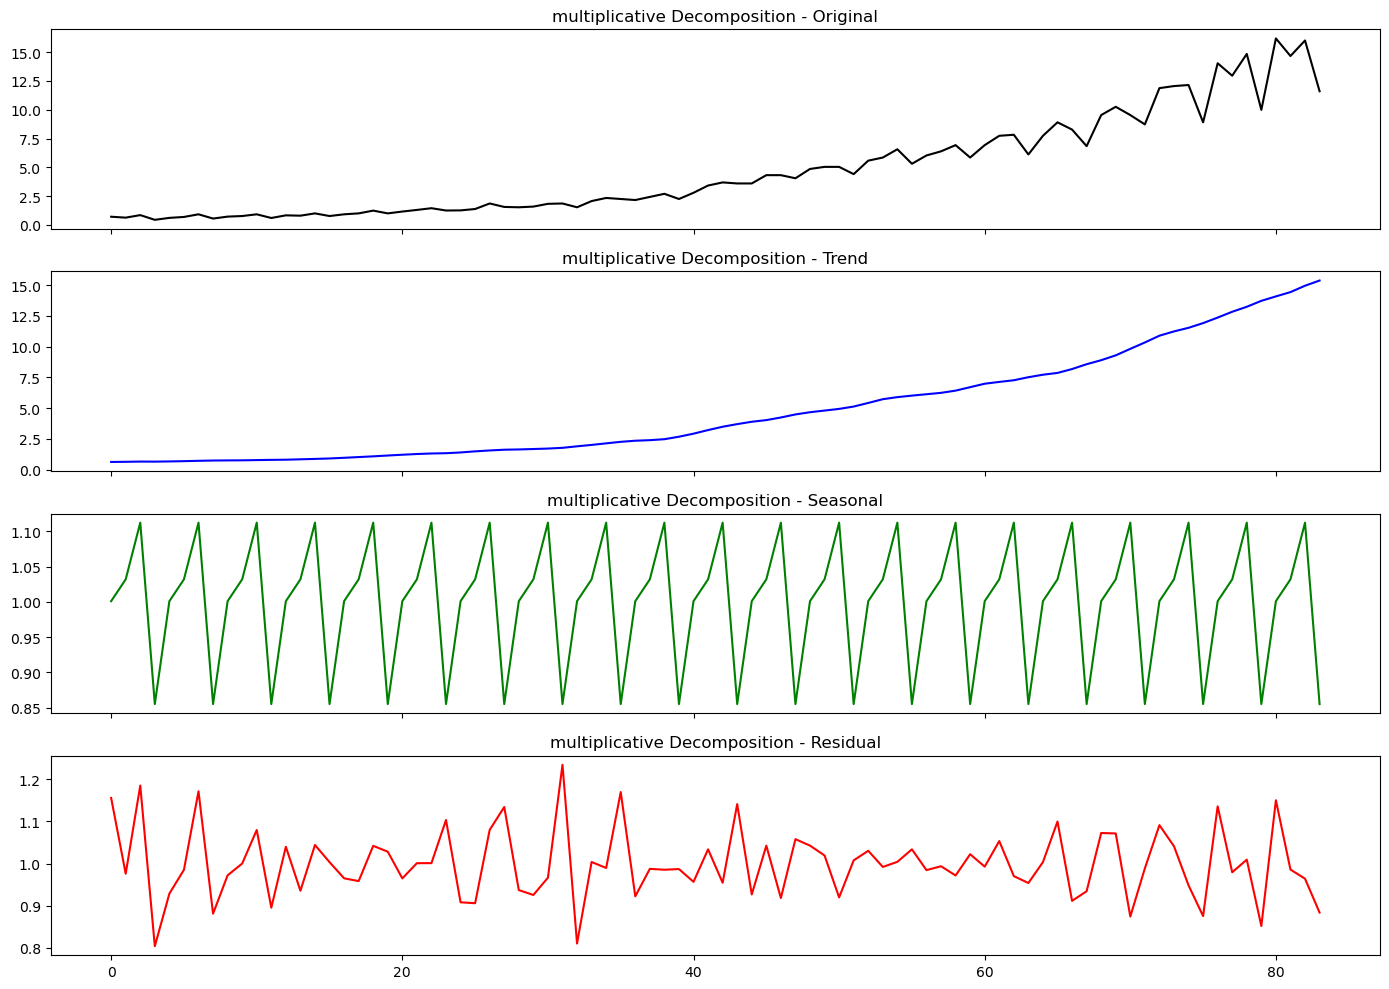

In [7]:
fig, axes = plt.subplots(4, 1, figsize = (14, 10), sharex = True)

axes[0].plot(result.observed, color = "black")
axes[0].set_title("multiplicative Decomposition - Original")

axes[1].plot(result.trend, color = "blue")
axes[1].set_title("multiplicative Decomposition - Trend")

axes[2].plot(result.seasonal, color = "green")
axes[2].set_title("multiplicative Decomposition - Seasonal")

axes[3].plot(result.resid, color = "red")
axes[3].set_title("multiplicative Decomposition - Residual")

plt.tight_layout()
plt.show()

In [8]:
df.shape

(84, 2)

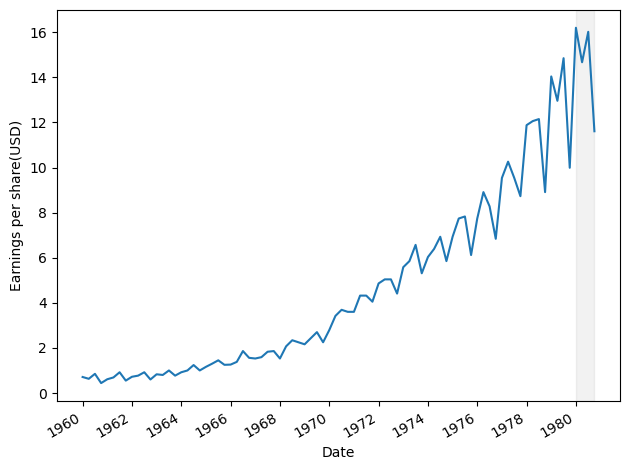

In [9]:
# 선 그래프 시각화
fig, ax = plt.subplots()

ax.plot(df["date"], df["data"])

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

In [10]:
# 훈련/테스트 데이터 분할
train = df.iloc[:-4]
test = df.iloc[-4:]

In [11]:
train.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [12]:
train.tail()

,date,data
75,1978-10-01,8.91
76,1979-01-01,14.04
77,1979-04-02,12.96
78,1979-07-02,14.85
79,1979-10-01,9.99


In [13]:
test

,date,data
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


## 과거 평균 기반 베이스라인 모델 구현

In [17]:
historical_mean = train["data"].mean()
historical_mean

np.float64(4.308499987499999)

- 1960년부터 1979년 말까지 존슨앤드존슨의 분기별 EPS는 평균 4.31달러

In [18]:
test.loc[:, "pred_mean"] = historical_mean

In [19]:
test.head()

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


- 평가 지표
    - 평균절대백분율오차(mean absolute percentage error, MAPE)
        - 데이터의 규모에 영향을 받지 않고 백분율로 오차를 표현
        - 예측값이 관측값과 평균적으로 얼마나 차이가 나는지를 백분율로 표현
        - $$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$
 
        - $y_i$ : i시점의 실제값
        - $\hat{y}_i$ : i시점의 예측값
        - $n$ : 예측 횟수
            - 이번 예시에서는 1980년 4번의 분기를 예측하므로 n = 4
         
        - 실젯값에서 예측값을 뺀 다음 그 결과를 실젯값으로 나눠 오차 백분율을 구하고, 백분율의 절대값을 구함. 이 작업을 각 n개 시점에 반복하고 결과를 합산한 후 예측 횟수로 나누기

In [20]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [21]:
mape_hist_mean = mape(test["data"], test["pred_mean"])
mape_hist_mean

np.float64(70.00752579965119)

- 베이스라인 모델의 예측값이 실제 존슨앤드존슨 분기별 주당순이익 실제값에 비해 평균 70% 정도 벗어남

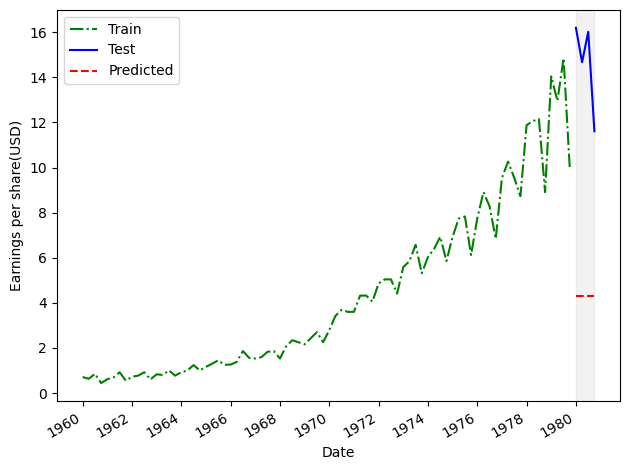

In [22]:
# 예측 시각화
fig, ax = plt.subplots()

ax.plot(train["date"], train["data"], "g-.", label = "Train")
ax.plot(test["date"], test["data"], "b-", label = "Test")
ax.plot(test["date"], test["pred_mean"], "r--", label = "Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)
ax.legend()

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

# 작년 평균으로 예측

- 분해 시계열 그래프를 참고하면 양의 추세가 존재하며 점점 가파르게 증가함을 알 수 있음
    - 따라서 1960년 EPS로는 1980년의 EPS 예측이 힘들 수 있음
    - 최근 기간의 평균을 사용해서 개선 시도

In [26]:
last_year_mean = train["data"].iloc[-4:].mean()
last_year_mean

np.float64(12.96)

In [27]:
test.loc[:, "pred_last_yr_mean"] = last_year_mean

In [28]:
test.head()

,date,data,pred_mean,pred_last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [29]:
mape_last_year_mean = mape(test["data"], test["pred_last_yr_mean"])
mape_last_year_mean

np.float64(15.5963680725103)

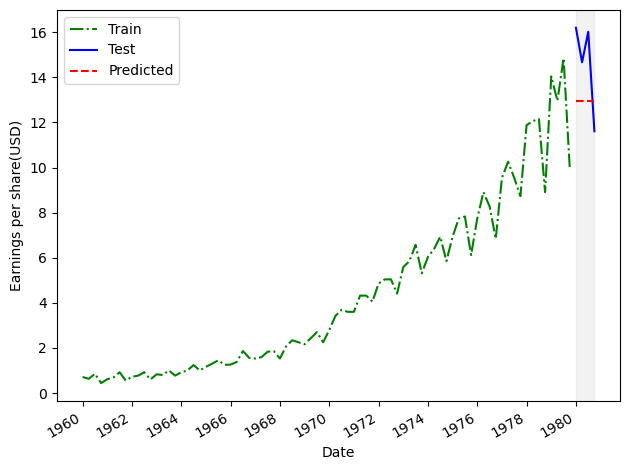

In [30]:
# 예측 시각화
fig, ax = plt.subplots()

ax.plot(train["date"], train["data"], "g-.", label = "Train")
ax.plot(test["date"], test["data"], "b-", label = "Test")
ax.plot(test["date"], test["pred_last_yr_mean"], "r--", label = "Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)
ax.legend()

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

- MAPE가 70%에서 15.6%로 줄어들어 이전 베이스라인 모델보다 성능이 확실히 개선되었음

- 미래의 값이 너무 멀지 않은 과거의 값과 연관이 있을 가능성이 높음
    - 자기상관관계(autocorrelation)

# 마지막으로 측정된 값으로 예측

- 가설 : 훈련 집합 중 마지막으로 측정된 값을 베이스라인 모델로 사용한다면 더 나은 예측을 얻을 수 있을 것이다.

In [33]:
last = train["data"].iloc[-1]
last

np.float64(9.99)

- 1979년 마지막 분기 EPS는 9.99 달러임
    - 존슨앤드존슨의 1980년 4분기 주당순이익은 9.99 달러로 예측

In [34]:
test.loc[:, "pred_last"] = last
test

,date,data,pred_mean,pred_last_yr_mean,pred_last
80,1980-01-01,16.20,4.3085,12.96,9.99
81,1980-04-01,14.67,4.3085,12.96,9.99
82,1980-07-02,16.02,4.3085,12.96,9.99
83,1980-10-01,11.61,4.3085,12.96,9.99


In [35]:
mape_last = mape(test["data"], test["pred_last"])
mape_last

np.float64(30.457277908606535)

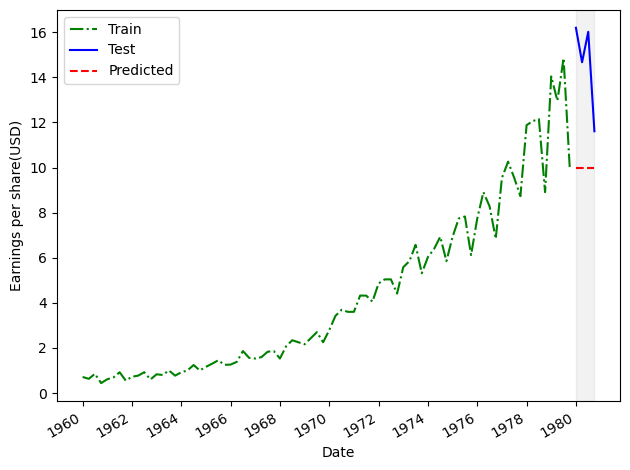

In [36]:
# 예측 시각화
fig, ax = plt.subplots()

ax.plot(train["date"], train["data"], "g-.", label = "Train")
ax.plot(test["date"], test["data"], "b-", label = "Test")
ax.plot(test["date"], test["pred_last"], "r--", label = "Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)
ax.legend()

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

- 마지막해 평균 EPS를 사용한 모델 MAPE : 15.6%

- 마지막 값을 사용한 모델 MAPE : 30.45%

- EPS가 처음 3번의 분기 동안은 높았다가 마지막 분기에는 하락하는 주기적인 행동을 보임
    - 마지막 측정값을 사용하면 계절성을 반영하지 못해 좋지 않은 결과에 도달

# 단순한 계절적 예측

- 마지막으로 측정된 주기가 미래에도 반복됨(계절성)

- 1979년 첫 분기 EPS를 사용하여 1980년 첫 분기 예측
    - 2, 3, 4분기에 대해서도 반복

In [38]:
test.loc[:, "pred_last_season"] = train["data"].iloc[-4:].values
test

,date,data,pred_mean,pred_last_yr_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [39]:
mape_naive_seasonal = mape(test["data"], test["pred_last_season"])
mape_naive_seasonal

np.float64(11.561658552433654)

- 모든 베이스라인 모델 중 가장 낮은 MAPE

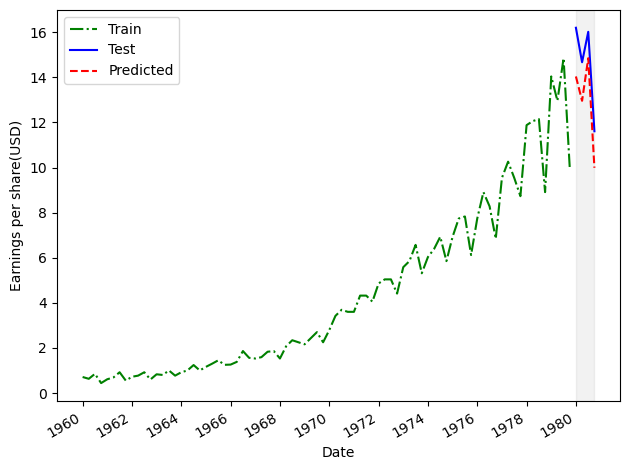

In [40]:
# 예측 시각화
fig, ax = plt.subplots()

ax.plot(train["date"], train["data"], "g-.", label = "Train")
ax.plot(test["date"], test["data"], "b-", label = "Test")
ax.plot(test["date"], test["pred_last_season"], "r--", label = "Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)
ax.legend()

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

# 정리

- 전체 평균 : 70%
- 마지막 해 평균 : 15%
- 마지막 값 : 30%
- 계절성 기반 : 11%

- 단순한 계절적 예측을 사용하는 베이스라인 모델이 가장 낮은 MAPE 를 보이며, 성능이 가장 우수

- 베이스라인 모델은 비교의 기준이 됨
    - 통계적 학습이나 딥러닝 기술을 적용하여 더 복잡한 모델을 개발한 뒤, 테스트 집합에 대해 평가하고 오차 지표를 확인하며 베이스라인 모델과 비교